In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

deliveries_df = pd.read_csv('/content/deliveries.csv')

display(deliveries_df.head())

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [15]:
powerplay_df = deliveries_df[deliveries_df['over'].between(1, 6)].copy()


powerplay_df['bowler_runs'] = powerplay_df['batsman_runs'] + powerplay_df['extra_runs'].fillna(0).apply(lambda x: x if x in [1,2,3,4,5] else 0)


powerplay_runs = powerplay_df.groupby('bowler')['total_runs'].sum().reset_index()
powerplay_runs.rename(columns={'total_runs': 'pp_total_runs'}, inplace=True)


powerplay_legal_balls = powerplay_df[~powerplay_df['extras_type'].isin(['wides', 'noballs'])]
powerplay_legal_balls_count = powerplay_legal_balls.groupby('bowler').size().reset_index(name='pp_legal_balls')


powerplay_stats = pd.merge(powerplay_runs, powerplay_legal_balls_count, on='bowler', how='left')


powerplay_stats['pp_overs'] = powerplay_stats['pp_legal_balls'] / 6

powerplay_stats['pp_economy'] = powerplay_stats['pp_total_runs'] / powerplay_stats['pp_overs']

display(powerplay_stats.sort_values(by='pp_economy').head())

,bowler,pp_total_runs,pp_legal_balls,pp_overs,pp_economy
72,BMAJ Mendis,2,6,1.0,2.000000
403,Shivam Sharma,2,6,1.0,2.000000
384,SM Harwood,7,18,3.0,2.333333
128,GR Napier,3,6,1.0,3.000000
261,MW Short,3,6,1.0,3.000000


In [16]:
death_over_df = deliveries_df[deliveries_df['over'].between(16, 20)].copy()


death_over_df['bowler_runs'] = death_over_df['batsman_runs'] + death_over_df['extra_runs'].fillna(0).apply(lambda x: x if x in [1,2,3,4,5] else 0)


death_over_runs = death_over_df.groupby('bowler')['total_runs'].sum().reset_index()
death_over_runs.rename(columns={'total_runs': 'do_total_runs'}, inplace=True)


death_over_legal_balls = death_over_df[~death_over_df['extras_type'].isin(['wides', 'noballs'])]
death_over_legal_balls_count = death_over_legal_balls.groupby('bowler').size().reset_index(name='do_legal_balls')


death_over_stats = pd.merge(death_over_runs, death_over_legal_balls_count, on='bowler', how='left')


death_over_stats['do_overs'] = death_over_stats['do_legal_balls'] / 6


death_over_stats['do_economy'] = death_over_stats['do_total_runs'] / death_over_stats['do_overs']


bowler_economy_stats = pd.merge(powerplay_stats, death_over_stats, on='bowler', how='inner')


qualifying_bowlers = bowler_economy_stats[(bowler_economy_stats['pp_overs'] >= 20) & (bowler_economy_stats['do_overs'] >= 20)]

display(qualifying_bowlers.head())


print("\nTop 10 most economical bowlers in Powerplay (min 20 PP overs & 20 DO overs):")
display(qualifying_bowlers.sort_values(by='pp_economy').head(10))

,bowler,pp_total_runs,pp_legal_balls,pp_overs,pp_economy,do_total_runs,do_legal_balls,do_overs,do_economy
5,A Mishra,527,456,76.000000,6.934211,471,287,47.833333,9.846690
7,A Nehra,1223,949,158.166667,7.732350,633,419,69.833333,9.064439
9,A Nortje,521,366,61.000000,8.540984,584,336,56.000000,10.428571
10,A Singh,294,246,41.000000,7.170732,256,149,24.833333,10.308725
17,AB Agarkar,349,234,39.000000,8.948718,266,158,26.333333,10.101266



Top 10 most economical bowlers in Powerplay (min 20 PP overs & 20 DO overs):


,bowler,pp_total_runs,pp_legal_balls,pp_overs,pp_economy,do_total_runs,do_legal_balls,do_overs,do_economy
98,DP Nannes,207,216,36.000000,5.750000,267,184,30.666667,8.706522
199,M Muralitharan,260,258,43.000000,6.046512,226,155,25.833333,8.748387
136,JC Archer,360,336,56.000000,6.428571,531,317,52.833333,10.050473
324,SP Narine,1277,1158,193.000000,6.616580,1003,739,123.166667,8.143437
51,Azhar Mahmood,180,162,27.000000,6.666667,284,171,28.500000,9.964912
144,JJ Bumrah,1171,1050,175.000000,6.691429,1601,1115,185.833333,8.615247
262,R Ashwin,1517,1330,221.666667,6.843609,491,331,55.166667,8.900302
318,SL Malinga,1077,943,157.166667,6.852598,1252,917,152.833333,8.191930
104,DW Steyn,1004,876,146.000000,6.876712,792,532,88.666667,8.932331
118,Harbhajan Singh,1065,923,153.833333,6.923077,258,177,29.500000,8.745763


In [9]:
death_over_df = deliveries_df[deliveries_df['over'].between(16, 20)].copy()


death_over_df['bowler_runs'] = death_over_df['batsman_runs'] + death_over_df['extra_runs'].fillna(0).apply(lambda x: x if x in [1,2,3,4,5] else 0)


death_over_runs = death_over_df.groupby('bowler')['total_runs'].sum().reset_index()
death_over_runs.rename(columns={'total_runs': 'do_total_runs'}, inplace=True)


death_over_legal_balls = death_over_df[~death_over_df['extras_type'].isin(['wides', 'noballs'])]
death_over_legal_balls_count = death_over_legal_balls.groupby('bowler').size().reset_index(name='do_legal_balls')


death_over_stats = pd.merge(death_over_runs, death_over_legal_balls_count, on='bowler', how='left')


death_over_stats['do_overs'] = death_over_stats['do_legal_balls'] / 6

death_over_stats['do_economy'] = death_over_stats['do_total_runs'] / death_over_stats['do_overs']

display(death_over_stats.sort_values(by='do_economy').head())

,bowler,do_total_runs,do_legal_balls,do_overs,do_economy
20,AC Gilchrist,0,1,0.166667,0.0
231,MP Yadav,0,1,0.166667,0.0
249,ND Doshi,1,6,1.000000,1.0
224,MJ Santner,1,6,1.000000,1.0
99,DJ Muthuswami,1,6,1.000000,1.0


In [10]:

bowler_economy_stats = pd.merge(powerplay_stats, death_over_stats, on='bowler', how='inner')


qualifying_bowlers = bowler_economy_stats[(bowler_economy_stats['pp_overs'] >= 20) & (bowler_economy_stats['do_overs'] >= 20)]

display(qualifying_bowlers.head())


print("\nTop 10 most economical bowlers in Powerplay (min 20 PP overs & 20 DO overs):")
display(qualifying_bowlers.sort_values(by='pp_economy').head(10))


,bowler,pp_total_runs,pp_legal_balls,pp_overs,pp_economy,do_total_runs,do_legal_balls,do_overs,do_economy
5,A Mishra,527,456,76.000000,6.934211,471,287,47.833333,9.846690
7,A Nehra,1223,949,158.166667,7.732350,633,419,69.833333,9.064439
9,A Nortje,521,366,61.000000,8.540984,584,336,56.000000,10.428571
10,A Singh,294,246,41.000000,7.170732,256,149,24.833333,10.308725
17,AB Agarkar,349,234,39.000000,8.948718,266,158,26.333333,10.101266



Top 10 most economical bowlers in Powerplay (min 20 PP overs & 20 DO overs):


,bowler,pp_total_runs,pp_legal_balls,pp_overs,pp_economy,do_total_runs,do_legal_balls,do_overs,do_economy
98,DP Nannes,207,216,36.000000,5.750000,267,184,30.666667,8.706522
199,M Muralitharan,260,258,43.000000,6.046512,226,155,25.833333,8.748387
136,JC Archer,360,336,56.000000,6.428571,531,317,52.833333,10.050473
324,SP Narine,1277,1158,193.000000,6.616580,1003,739,123.166667,8.143437
51,Azhar Mahmood,180,162,27.000000,6.666667,284,171,28.500000,9.964912
144,JJ Bumrah,1171,1050,175.000000,6.691429,1601,1115,185.833333,8.615247
262,R Ashwin,1517,1330,221.666667,6.843609,491,331,55.166667,8.900302
318,SL Malinga,1077,943,157.166667,6.852598,1252,917,152.833333,8.191930
104,DW Steyn,1004,876,146.000000,6.876712,792,532,88.666667,8.932331
118,Harbhajan Singh,1065,923,153.833333,6.923077,258,177,29.500000,8.745763


/tmp/ipykernel_9563/4017012197.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


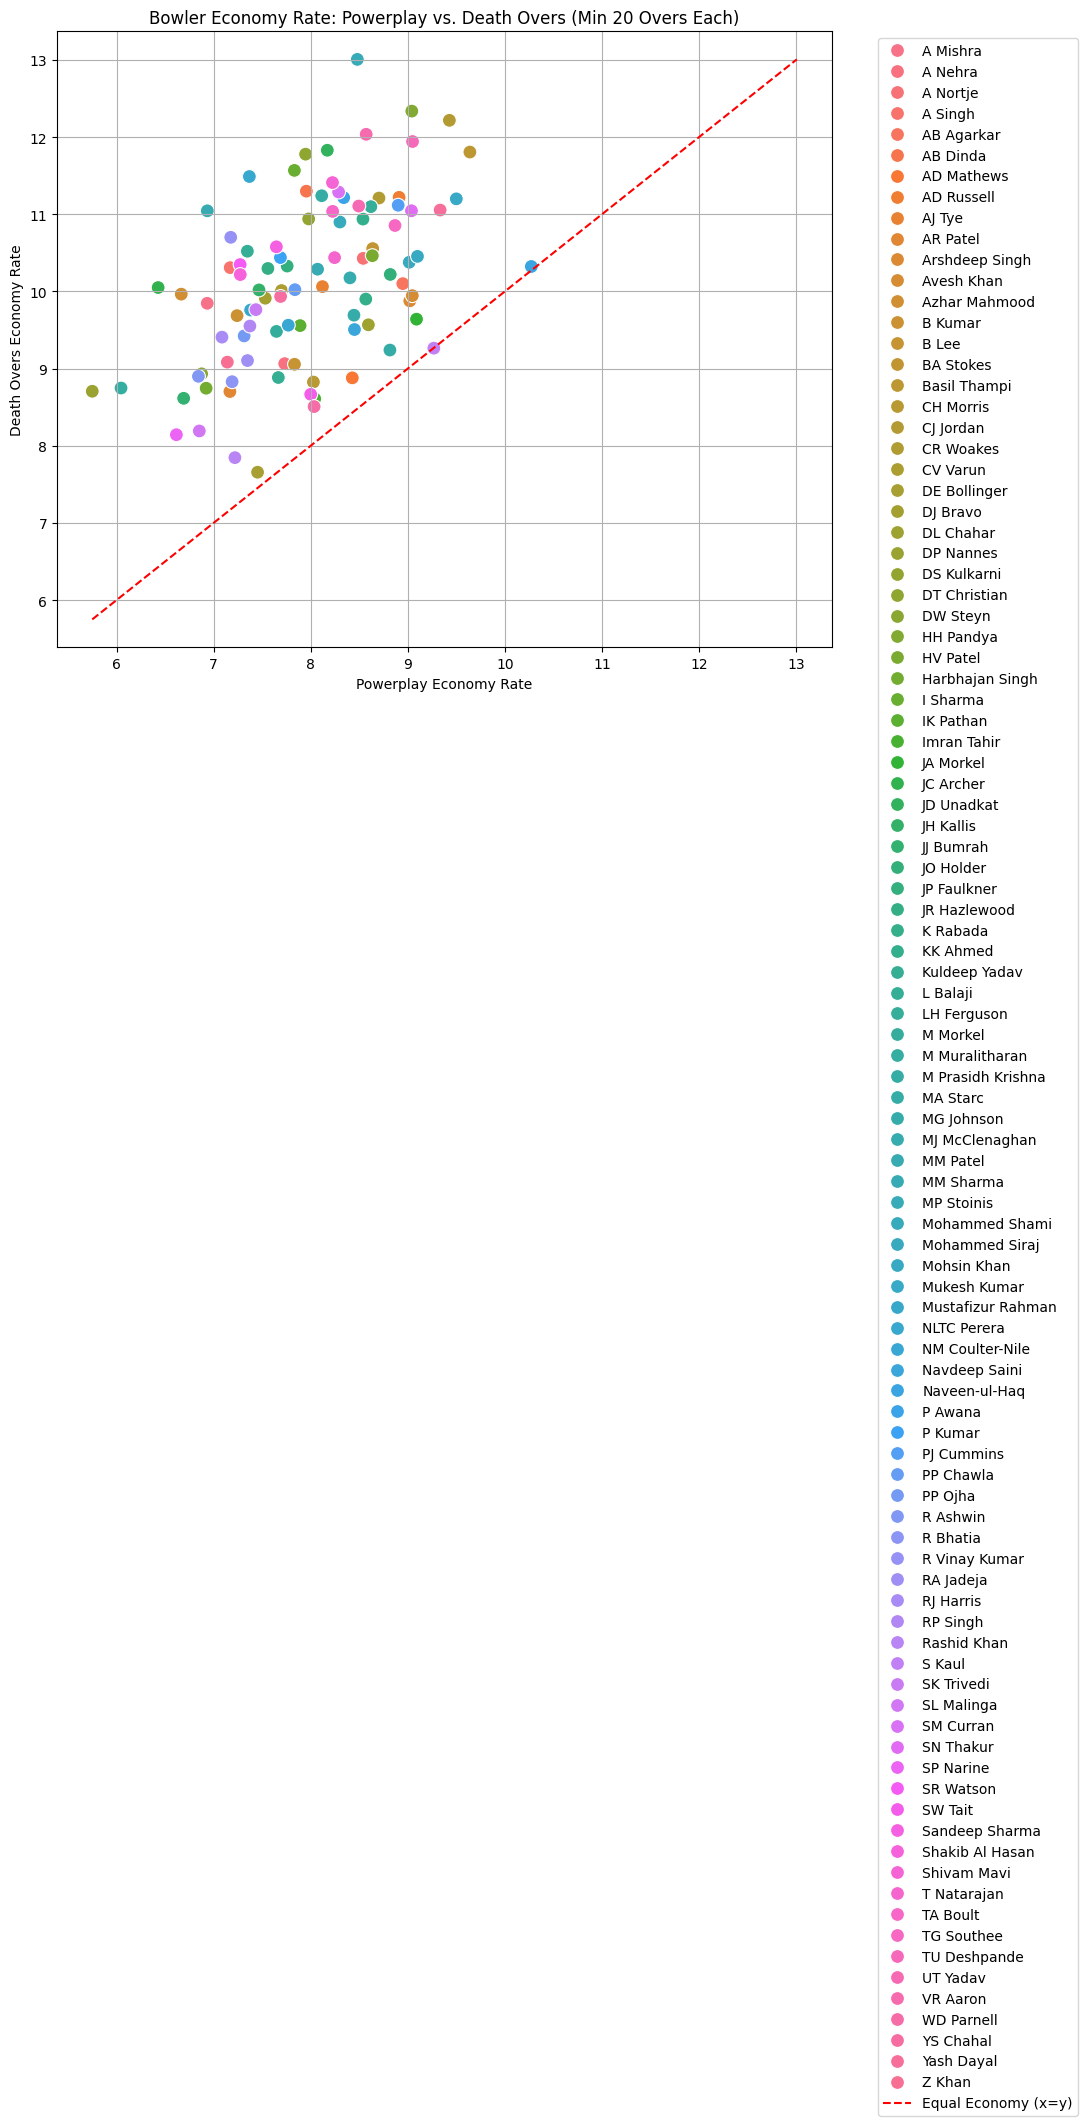

In [11]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=qualifying_bowlers, x='pp_economy', y='do_economy', hue='bowler', s=100)

max_economy = max(qualifying_bowlers['pp_economy'].max(), qualifying_bowlers['do_economy'].max())
min_economy = min(qualifying_bowlers['pp_economy'].min(), qualifying_bowlers['do_economy'].min())
plt.plot([min_economy, max_economy], [min_economy, max_economy], 'r--', label='Equal Economy (x=y)')

plt.title('Bowler Economy Rate: Powerplay vs. Death Overs (Min 20 Overs Each)')
plt.xlabel('Powerplay Economy Rate')
plt.ylabel('Death Overs Economy Rate')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_9563/3143655531.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


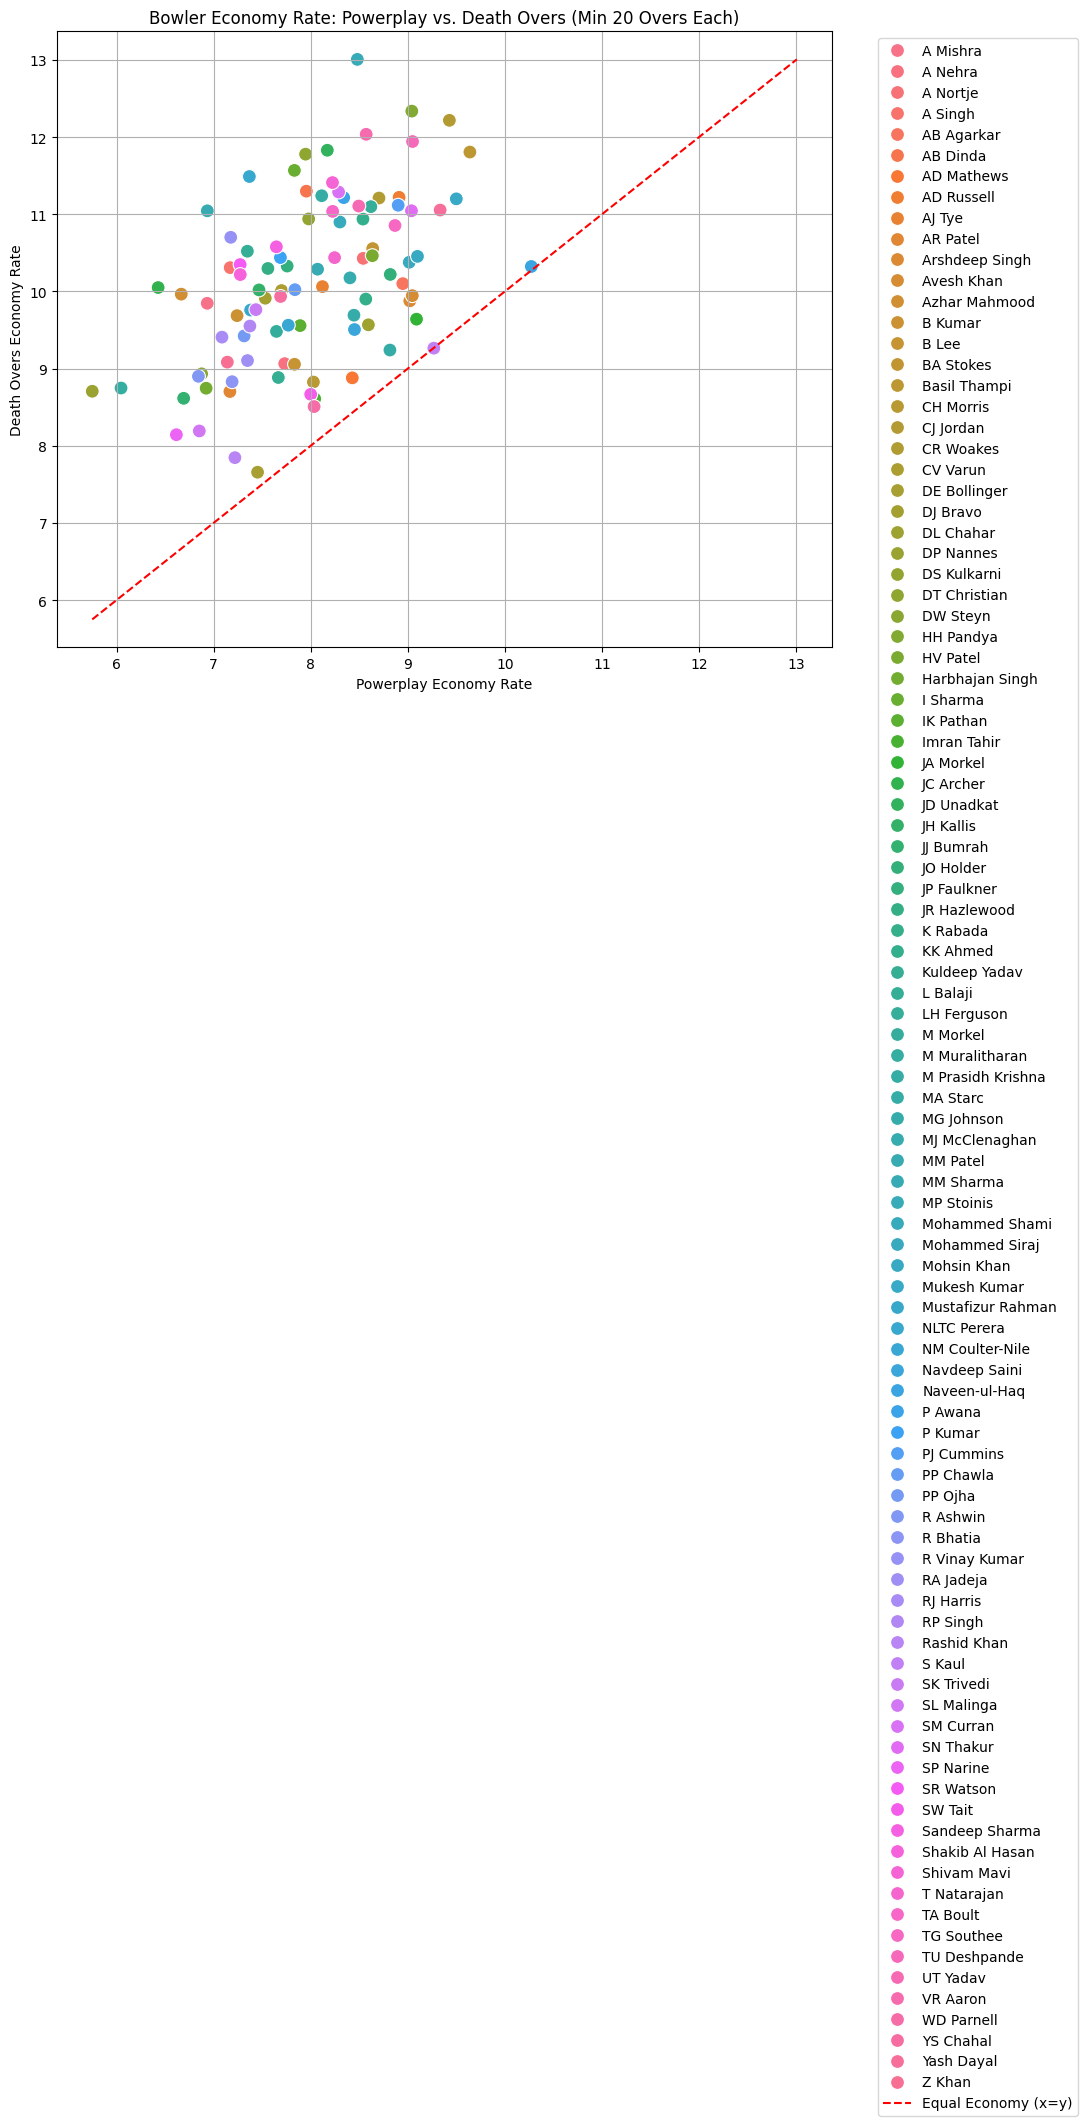

In [6]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=qualifying_bowlers, x='pp_economy', y='do_economy', hue='bowler', s=100)

max_economy = max(qualifying_bowlers['pp_economy'].max(), qualifying_bowlers['do_economy'].max())
min_economy = min(qualifying_bowlers['pp_economy'].min(), qualifying_bowlers['do_economy'].min())
plt.plot([min_economy, max_economy], [min_economy, max_economy], 'r--', label='Equal Economy (x=y)')

plt.title('Bowler Economy Rate: Powerplay vs. Death Overs (Min 20 Overs Each)')
plt.xlabel('Powerplay Economy Rate')
plt.ylabel('Death Overs Economy Rate')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()